# Klasifikacija objekata na CIFAR-10 skupu primenom veštačkih neuronskih mreža

Na istom zadatku poredimo tri pristupa — neuronsku mrežu iz **scikit-learn**, gustu mrežu (**MLP**) i konvolutivnu mrežu (**CNN**) u **Keras/TensorFlow** — uz detaljnu pripremu, analizu podataka i evaluaciju.

## 1. Uvod
Cilj je naučiti model da sliku svrsta u jednu od 10 kategorija. Detaljna objašnjenja pojmova su u pratećem dokumentu.

Učitavamo biblioteke i fiksiramo *seed* da rezultati budu ponovljivi.

In [ ]:
import os, glob, random, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')
print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)

TensorFlow: 2.20.0 | Keras: 3.13.2


## 2. Podaci
Skup preuzimamo sa **Kaggle-a** preko `kagglehub` — ispisujemo tačan izvor, lokaciju i klase (nazivi foldera).

In [ ]:
try:
    import kagglehub
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
    import kagglehub

dataset_path = kagglehub.dataset_download("ayush1220/cifar10")
train_dir = next(p for p in glob.glob(os.path.join(dataset_path, "**", "train"), recursive=True) if os.path.isdir(p))
test_dir  = next(p for p in glob.glob(os.path.join(dataset_path, "**", "test"),  recursive=True) if os.path.isdir(p))
print("Kaggle skup:", dataset_path)
print("Train folder:", train_dir, "-> klase:", sorted(os.listdir(train_dir)))
print("Test  folder:", test_dir)

100%|██████████| 139M/139M [00:01<00:00, 146MB/s]

Extracting files...


Kaggle skup: /root/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2
Train folder: /root/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2/cifar10/train -> klase: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Test  folder: /root/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2/cifar10/test


Slike učitavamo iz foldera po klasama u nizove oblika (N, 32, 32, 3); imena klasa čitamo direktno iz naziva foldera. Pošto stižu poređane po klasi, odmah ih promešamo (fiksni seed).

In [ ]:
def load_split(directory):
    ds = keras.utils.image_dataset_from_directory(
        directory, labels='inferred', label_mode='int', color_mode='rgb',
        image_size=(32, 32), batch_size=256, shuffle=False)
    X = np.concatenate([b.numpy() for b, _ in ds]).astype('uint8')
    y = np.concatenate([l.numpy() for _, l in ds]).reshape(-1, 1)
    return X, y, ds.class_names

# Imena klasa čitamo direktno iz naziva foldera (azbučni red = standardni CIFAR red).
x_train, y_train, class_names = load_split(train_dir)
x_test,  y_test,  _           = load_split(test_dir)

# Slike stižu poređane po klasi (folder po folder) -> mešamo ih fiksnim seed-om,
# da pregledi budu raznovrsni i da nijedan korak ne zavisi od redosleda.
rng = np.random.default_rng(SEED)
ptr = rng.permutation(len(x_train)); x_train, y_train = x_train[ptr], y_train[ptr]
pte = rng.permutation(len(x_test));  x_test,  y_test  = x_test[pte],  y_test[pte]
print("Trening:", x_train.shape, "| Test:", x_test.shape)
print("Klase (iz naziva foldera):", class_names)

Found 50000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
Trening: (50000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Klase (iz naziva foldera): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Sve dimenzije i broj klasa računamo **iz podataka**, ništa ručno ukucano.

In [ ]:
INPUT_SHAPE = x_train.shape[1:]                 # (32, 32, 3)
NUM_CLASSES = len(np.unique(y_train))           # 10
FLAT_DIM    = int(np.prod(INPUT_SHAPE))         # 3072
print(f"INPUT_SHAPE={INPUT_SHAPE}  NUM_CLASSES={NUM_CLASSES}  FLAT_DIM={FLAT_DIM}")
print(f"Ukupno trening slika: {x_train.shape[0]:,} | test slika: {x_test.shape[0]:,}")

INPUT_SHAPE=(32, 32, 3)  NUM_CLASSES=10  FLAT_DIM=3072
Ukupno trening slika: 50,000 | test slika: 10,000


### 2.1. Deskriptivna analiza (EDA)
Prolazimo kroz podatke pre modeliranja: kako slike izgledaju, koliko ih je po klasi, u kom su opsegu, i šta je 'tipičan' izgled svake klase.

Prvo 25 nasumičnih slika da potvrdimo da su ispravno učitane i označene.

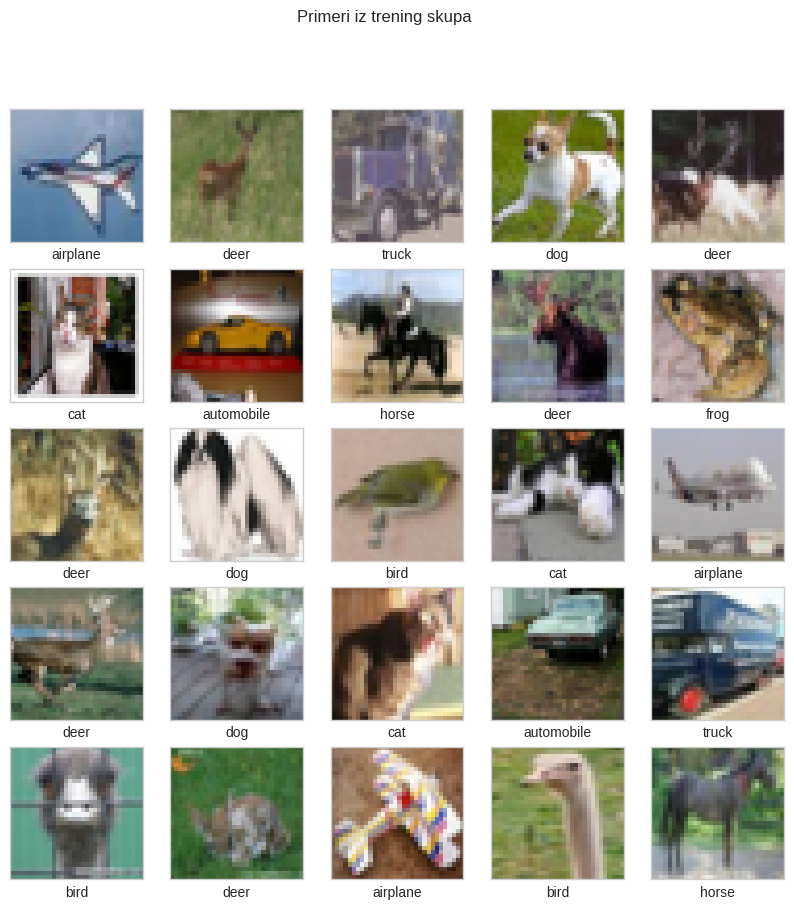

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1); plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.imshow(x_train[i]); plt.xlabel(class_names[int(y_train[i][0])])
plt.suptitle("Primeri iz trening skupa"); plt.show()

Po jedan čist primer iz svake klase — da vidimo kako izgleda svaka od 10 kategorija.

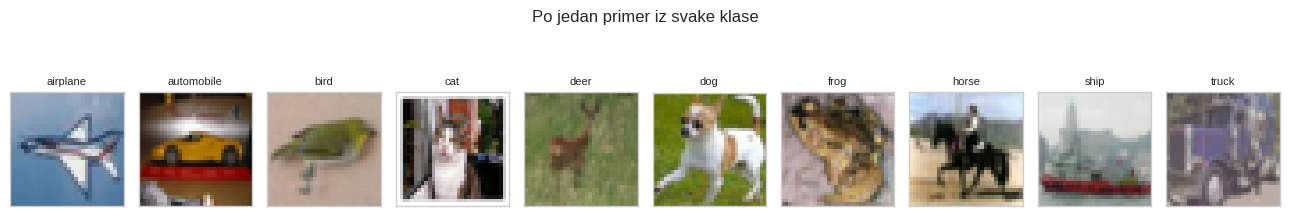

In [ ]:
plt.figure(figsize=(13, 2.6))
for c in range(NUM_CLASSES):
    ix = np.where(y_train.flatten() == c)[0][0]
    plt.subplot(1, 10, c + 1); plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.imshow(x_train[ix]); plt.title(class_names[c], fontsize=8)
plt.suptitle("Po jedan primer iz svake klase"); plt.tight_layout(); plt.show()

Balans skupa: koliko slika ima svaka klasa (iz stvarnih brojeva). Balansiran skup znači da je tačnost poštena mera.

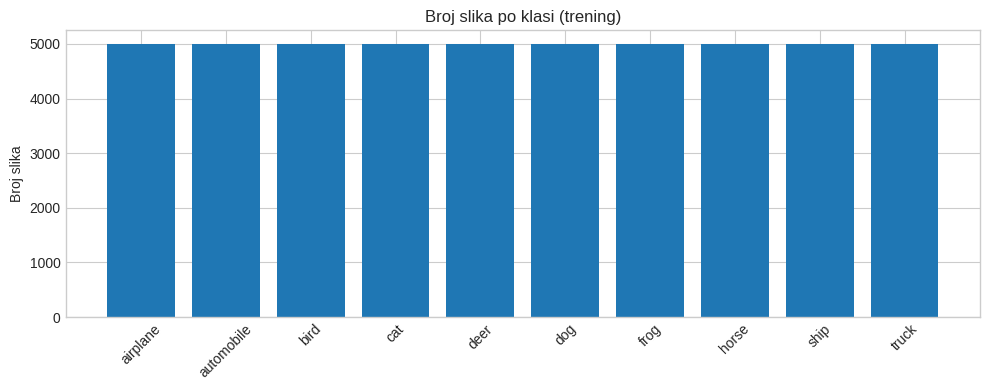

Min po klasi: 5000 | Max po klasi: 5000 | razlika: 0


In [ ]:
labels, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 4))
plt.bar([class_names[i] for i in labels], counts)
plt.title("Broj slika po klasi (trening)"); plt.xticks(rotation=45); plt.ylabel("Broj slika")
plt.tight_layout(); plt.show()
print("Min po klasi:", counts.min(), "| Max po klasi:", counts.max(),
      "| razlika:", counts.max() - counts.min())

**Kako slika izgleda za računar — matrica brojeva (pre skaliranja).** Prikazujemo gornji-levi ugao 8×8 jedne slike, crveni kanal; vrednosti su celi brojevi 0–255.

In [ ]:
img0 = x_train[0]
print("Oblik jedne slike:", img0.shape, "| tip:", img0.dtype)
print("Klasa ove slike:", class_names[int(y_train[0][0])])
print("\nGornji-levi ugao 8x8, CRVENI kanal (vrednosti 0-255):")
print(img0[:8, :8, 0])

Oblik jedne slike: (32, 32, 3) | tip: uint8
Klasa ove slike: airplane

Gornji-levi ugao 8x8, CRVENI kanal (vrednosti 0-255):
[[152 152 152 156 157 157 157 156]
 [151 151 151 154 155 155 155 154]
 [150 150 150 152 153 153 153 152]
 [150 150 150 151 151 149 148 148]
 [150 150 150 148 147 147 147 145]
 [148 148 148 146 145 144 144 141]
 [146 146 146 142 141 140 139 137]
 [145 145 145 140 139 137 136 134]]


Statistika piksela ukupno i **po kanalu** (crvena/zelena/plava) — pokazuje opseg i prosečnu jačinu svake boje.

In [ ]:
print(f"Ukupno: min={x_train.min()}, max={x_train.max()}, mean={x_train.mean():.1f}, std={x_train.std():.1f}")
for ci, cn in enumerate(['crvena', 'zelena', 'plava']):
    ch = x_train[..., ci]
    print(f"  {cn:7s}: mean={ch.mean():6.1f}  std={ch.std():5.1f}  min={ch.min()}  max={ch.max()}")

Ukupno: min=0, max=255, mean=120.7, std=64.2
  crvena : mean= 125.3  std= 63.0  min=0  max=255
  zelena : mean= 123.0  std= 62.1  min=0  max=255
  plava  : mean= 113.9  std= 66.7  min=0  max=255


Raspodela svih vrednosti piksela (na uzorku) — vidimo kako su tamni i svetli tonovi raspoređeni.

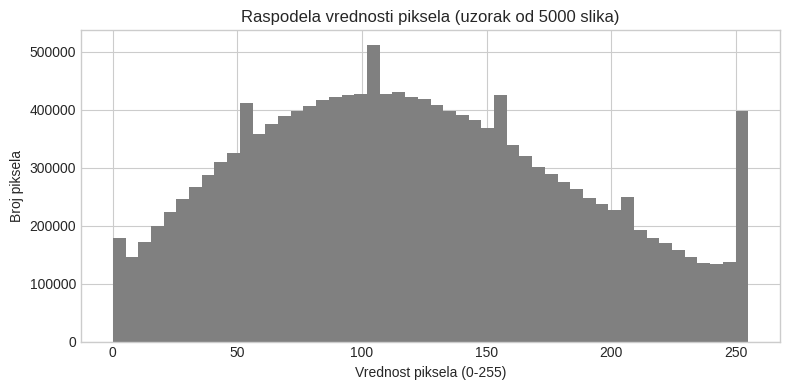

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(x_train[:5000].ravel(), bins=50, color='gray')
plt.title("Raspodela vrednosti piksela (uzorak od 5000 slika)")
plt.xlabel("Vrednost piksela (0-255)"); plt.ylabel("Broj piksela")
plt.tight_layout(); plt.show()

**Srednja (prosečna) slika po klasi** — prosek svih slika jedne klase otkriva 'tipičan' izgled i pozadinu (npr. plavo nebo/voda), tj. tragove koje model može da koristi.

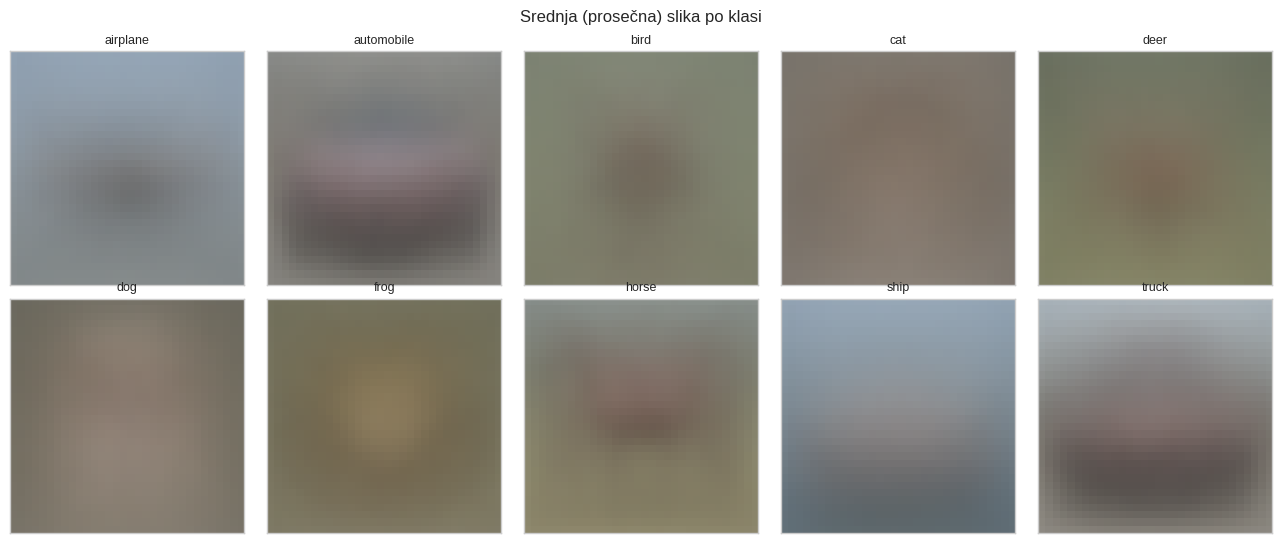

In [ ]:
plt.figure(figsize=(13, 5.5))
for c in range(NUM_CLASSES):
    mean_img = x_train[y_train.flatten() == c].mean(axis=0).astype('uint8')
    plt.subplot(2, 5, c + 1); plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.imshow(mean_img); plt.title(class_names[c], fontsize=9)
plt.suptitle("Srednja (prosečna) slika po klasi"); plt.tight_layout(); plt.show()

### 2.2. Priprema podataka
Slike skaliramo na opseg 0–1 (delimo sa 255), a labele pretvaramo u one-hot vektore.

In [ ]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32') / 255.0
y_train_enc  = to_categorical(y_train, NUM_CLASSES)
y_test_enc   = to_categorical(y_test,  NUM_CLASSES)

**Ista slika kao brojevi POSLE skaliranja (0–1)** — isti ugao 8×8 kao gore, ali sada su vrednosti podeljene sa 255. Ispod je i primer pretvaranja labele u one-hot.

In [ ]:
np.set_printoptions(precision=2, suppress=True)
print("Isti ugao 8x8, CRVENI kanal, POSLE skaliranja (vrednosti 0-1):")
print(x_train_norm[0][:8, :8, 0])
print(f"\nPre skaliranja:  min={x_train.min()}   max={x_train.max()}")
print(f"Posle skaliranja: min={x_train_norm.min():.2f}   max={x_train_norm.max():.2f}")
print("\nPrimer labele -> one-hot:")
print("  broj klase:", int(y_train[0][0]), "(", class_names[int(y_train[0][0])], ")")
print("  one-hot   :", y_train_enc[0].astype(int))

Isti ugao 8x8, CRVENI kanal, POSLE skaliranja (vrednosti 0-1):
[[0.6  0.6  0.6  0.61 0.62 0.62 0.62 0.61]
 [0.59 0.59 0.59 0.6  0.61 0.61 0.61 0.6 ]
 [0.59 0.59 0.59 0.6  0.6  0.6  0.6  0.6 ]
 [0.59 0.59 0.59 0.59 0.59 0.58 0.58 0.58]
 [0.59 0.59 0.59 0.58 0.58 0.58 0.58 0.57]
 [0.58 0.58 0.58 0.57 0.57 0.56 0.56 0.55]
 [0.57 0.57 0.57 0.56 0.55 0.55 0.55 0.54]
 [0.57 0.57 0.57 0.55 0.55 0.54 0.53 0.53]]

Pre skaliranja:  min=0   max=255
Posle skaliranja: min=0.00   max=1.00

Primer labele -> one-hot:
  broj klase: 0 ( airplane )
  one-hot   : [1 0 0 0 0 0 0 0 0 0]


Iz treninga izdvajamo 10% za **validaciju** (stratifikovano); **test čuvamo netaknut** do same evaluacije.

In [ ]:
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train_norm, y_train_enc, test_size=0.10, random_state=SEED, stratify=y_train)
print(f"Trening={x_tr.shape[0]}  Validacija={x_val.shape[0]}  Test(čuvan)={x_test_norm.shape[0]}")

Trening=45000  Validacija=5000  Test(čuvan)=10000


## 3. Modeli
Pravimo tri modela, od najjednostavnijeg ka najmoćnijem.

Baseline iz scikit-learn (`MLPClassifier`) na poduzorku — radi na CPU, zato ograničavamo veličinu i broj iteracija.

Slika → Flatten → 256 → fit → Test → predict → Accuracy/F1

In [ ]:
SUBSAMPLE = min(10000, x_tr.shape[0])
Xs = x_tr[:SUBSAMPLE].reshape(SUBSAMPLE, -1)
ys = np.argmax(y_tr[:SUBSAMPLE], axis=1)
sk_mlp = MLPClassifier(hidden_layer_sizes=(256,), max_iter=50, early_stopping=True, random_state=SEED)
sk_mlp.fit(Xs, ys)
sk_true = np.argmax(y_test_enc, axis=1)
sk_pred = sk_mlp.predict(x_test_norm.reshape(x_test_norm.shape[0], -1))
sk_acc  = accuracy_score(sk_true, sk_pred)
sk_f1   = f1_score(sk_true, sk_pred, average='macro')
print(f"scikit-learn MLP tačnost na testu: {sk_acc*100:.2f}%  |  macro-F1: {sk_f1:.3f}")

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


scikit-learn MLP tačnost na testu: 42.10%  |  macro-F1: 0.415


Keras MLP: sliku 'ispeglamo' u vektor i propustimo kroz dva gusta sloja sa dropout regularizacijom.

Slika → Flatten → 512 → Dropout → 256 → Softmax → Klasa

In [ ]:
def build_mlp_model():
    model = models.Sequential(name="MLP_Model")
    model.add(keras.Input(shape=INPUT_SHAPE))
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    return model

Keras CNN: konvolutivni slojevi sa `BatchNormalization` i `Dropout` — gleda sliku u krpicama i traži šare.

Conv → Pool → Conv → Pool → Flatten → Dense → Softmax

In [ ]:
def build_cnn_model():
    model = models.Sequential(name="CNN_Model")
    model.add(keras.Input(shape=INPUT_SHAPE))
    for filters in (32, 64):
        model.add(layers.Conv2D(filters, (3, 3), padding='same', activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Conv2D(filters, (3, 3), padding='same', activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))
        model.add(layers.Dropout(0.25))
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    return model

Pregled arhitekture oba modela i **broj parametara** — pokazuje da CNN pobeđuje načinom gledanja, ne veličinom.

In [ ]:
mlp_preview = build_mlp_model()
cnn_preview = build_cnn_model()
print("================ MLP ================"); mlp_preview.summary()
print("\n================ CNN ================"); cnn_preview.summary()
print(f"\nMLP parametara: {mlp_preview.count_params():,}")
print(f"CNN parametara: {cnn_preview.count_params():,}")

================ MLP ================


Model: "MLP_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,169,130 (8.27 MB)

 Trainable params: 2,168,746 (8.27 MB)

 Non-trainable params: 384 (1.50 KB)


MLP parametara: 1,707,274
CNN parametara: 2,169,130


## 4. Konfiguracija i trening
Isti uslovi za sve modele: do 40 epoha uz rano zaustavljanje koje prati validacionu tačnost i vraća najbolje težine — fer poređenje.

In [ ]:
BATCH_SIZE = 64
EPOCHS = 40
def compile_model(m):
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', mode='max',
                                           patience=8, restore_best_weights=True)

Treniramo Keras MLP i CNN pod istim uslovima. (Seed resetujemo neposredno pre treninga da ne zavisi od ranijih pregleda modela.)

In [ ]:
tf.random.set_seed(SEED)
def train(model):
    return model.fit(x_tr, y_tr, validation_data=(x_val, y_val),
                     batch_size=BATCH_SIZE, epochs=EPOCHS, callbacks=[early_stop], verbose=1)

t0 = time.time()
mlp_model = compile_model(build_mlp_model())
print("\n=== MLP ==="); hist_mlp = train(mlp_model)
cnn_model = compile_model(build_cnn_model())
print("\n=== CNN ==="); hist_cnn = train(cnn_model)
print(f"\nUkupno vreme treninga: {time.time()-t0:.0f} s")


=== MLP ===
Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.2847 - loss: 1.9653 - val_accuracy: 0.3666 - val_loss: 1.7678
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.3389 - loss: 1.8184 - val_accuracy: 0.3868 - val_loss: 1.7214
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3607 - loss: 1.7614 - val_accuracy: 0.4036 - val_loss: 1.6634
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3735 - loss: 1.7213 - val_accuracy: 0.4206 - val_loss: 1.6327
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3912 - loss: 1.6895 - val_accuracy: 0.4280 - val_loss: 1.6252
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3949 - loss: 1.6699 - val_accuracy: 0.4310 - val_loss: 1.6024
Epoch 7/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4104 - loss: 1.6410 - val_accuracy: 0.4330 - val_loss: 1.5918
Epoch 8/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4134 - loss: 1.6265 - 

## 5. Evaluacija i diskusija
Krive gubitka i tačnosti kroz epohe za MLP i CNN.

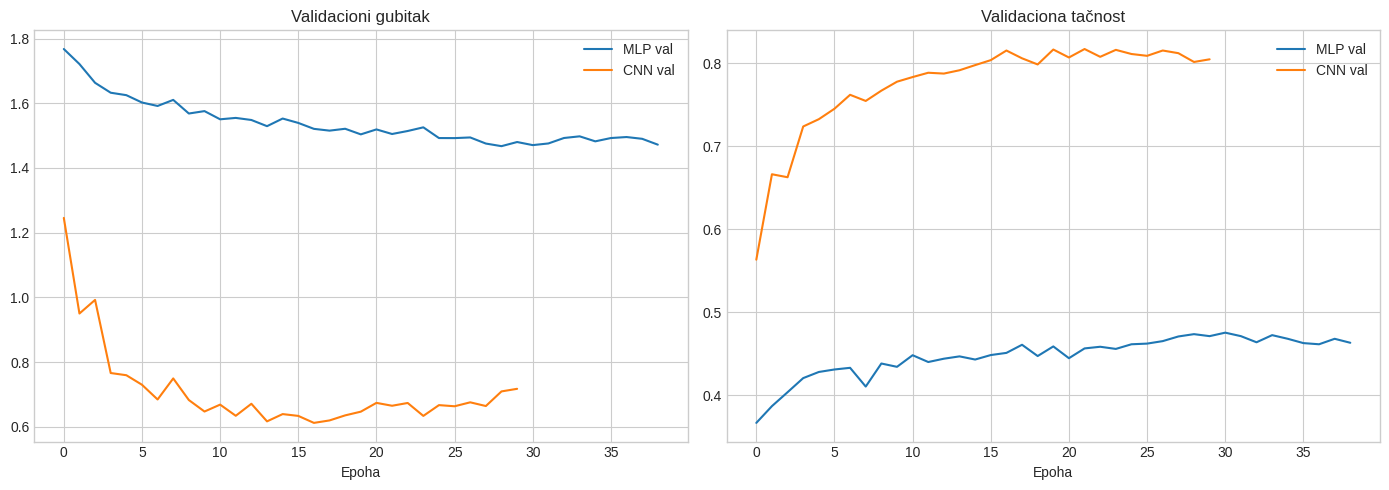

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for name, h in [("MLP", hist_mlp), ("CNN", hist_cnn)]:
    ax[0].plot(h.history['val_loss'], label=f"{name} val")
    ax[1].plot(h.history['val_accuracy'], label=f"{name} val")
ax[0].set_title("Validacioni gubitak"); ax[0].set_xlabel("Epoha"); ax[0].legend()
ax[1].set_title("Validaciona tačnost"); ax[1].set_xlabel("Epoha"); ax[1].legend()
plt.tight_layout(); plt.show()

scikit-learn baseline ima **svoju** krivu učenja — posebno, jer meri iteracije (ne epohe) i trenira na poduzorku.

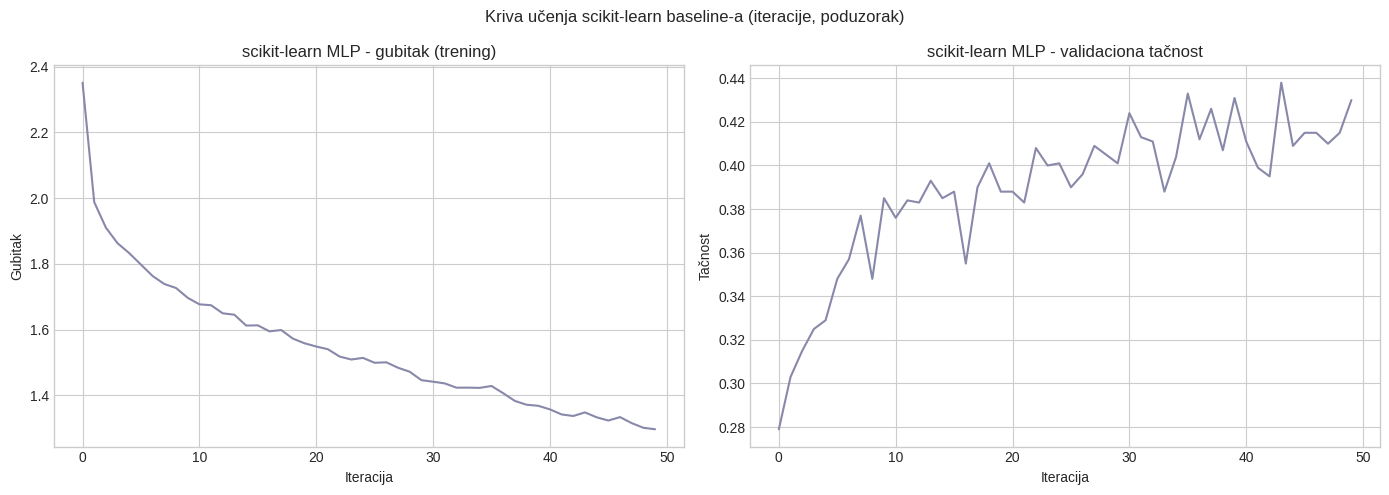

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(sk_mlp.loss_curve_, color='#8888aa'); ax[0].set_title("scikit-learn MLP - gubitak (trening)")
ax[0].set_xlabel("Iteracija"); ax[0].set_ylabel("Gubitak")
ax[1].plot(sk_mlp.validation_scores_, color='#8888aa'); ax[1].set_title("scikit-learn MLP - validaciona tačnost")
ax[1].set_xlabel("Iteracija"); ax[1].set_ylabel("Tačnost")
plt.suptitle("Kriva učenja scikit-learn baseline-a (iteracije, poduzorak)")
plt.tight_layout(); plt.show()

### 5.1. Analiza preobučavanja
Za CNN poredimo tačnost na treningu i validaciji; veći razmak = jače 'bubanje napamet'. Dropout i BatchNorm ga ublažavaju, a augmentacija bi bila logičan sledeći korak.

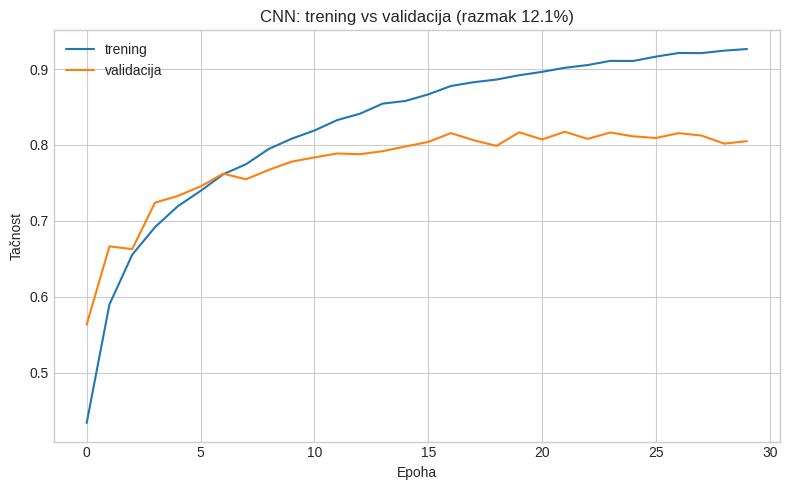

In [ ]:
h = hist_cnn
plt.figure(figsize=(8, 5))
plt.plot(h.history['accuracy'], label='trening')
plt.plot(h.history['val_accuracy'], label='validacija')
gap = (h.history['accuracy'][-1] - h.history['val_accuracy'][-1]) * 100
plt.title(f"CNN: trening vs validacija (razmak {gap:.1f}%)")
plt.xlabel("Epoha"); plt.ylabel("Tačnost"); plt.legend(); plt.tight_layout(); plt.show()

Finalna tačnost na **čuvanom test skupu** — prvi i jedini put da ga koristimo.

In [ ]:
keras_models = {"Keras MLP": mlp_model, "Keras CNN": cnn_model}
y_true = np.argmax(y_test_enc, axis=1)
results = {"scikit-learn MLP": (sk_acc, f1_score(y_true, sk_pred, average='macro'))}
preds = {}
for name, m in keras_models.items():
    p = np.argmax(m.predict(x_test_norm, verbose=0), axis=1)
    preds[name] = p
    results[name] = (accuracy_score(y_true, p), f1_score(y_true, p, average='macro'))
    print(f"{name}: tačnost={results[name][0]*100:.2f}%  macro-F1={results[name][1]:.3f}")

Keras MLP: tačnost=47.58%  macro-F1=0.468
Keras CNN: tačnost=80.31%  macro-F1=0.803


Vizuelno poređenje sva tri modela na test skupu.

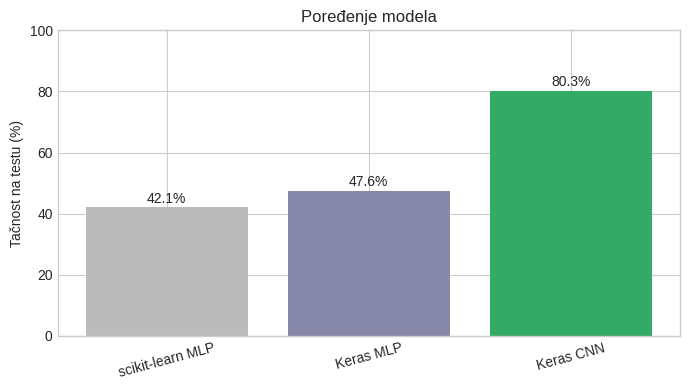

In [ ]:
plt.figure(figsize=(7, 4))
names = list(results.keys()); accs = [results[n][0]*100 for n in names]
bars = plt.bar(names, accs, color=['#bbbbbb', '#8888aa', '#33aa66'])
for b, a in zip(bars, accs):
    plt.text(b.get_x()+b.get_width()/2, a+1.5, f"{a:.1f}%", ha='center', fontsize=10)
plt.ylabel("Tačnost na testu (%)"); plt.title("Poređenje modela"); plt.ylim(0, 100)
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

Najbolji model biramo po tačnosti; za njega crtamo matricu konfuzije (broj zamena po paru klasa).

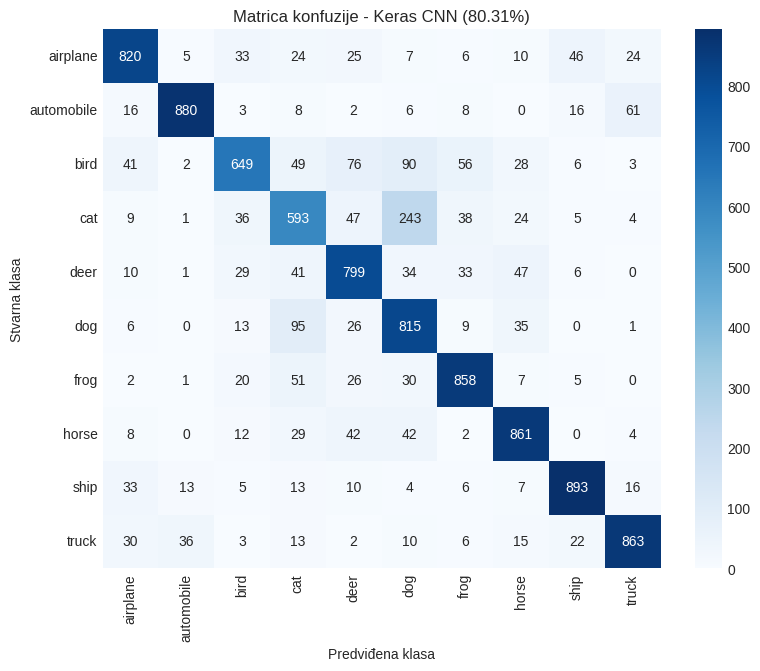

In [ ]:
best_name = max(preds, key=lambda n: results[n][0])
best_pred = preds[best_name]
best_model = keras_models[best_name]
cm = confusion_matrix(y_true, best_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predviđena klasa"); plt.ylabel("Stvarna klasa")
plt.title(f"Matrica konfuzije - {best_name} ({results[best_name][0]*100:.2f}%)"); plt.show()

Ista matrica ali **u procentima po redu** — koliko % svake stvarne klase je gde otišlo (lakše za čitanje od golih brojeva).

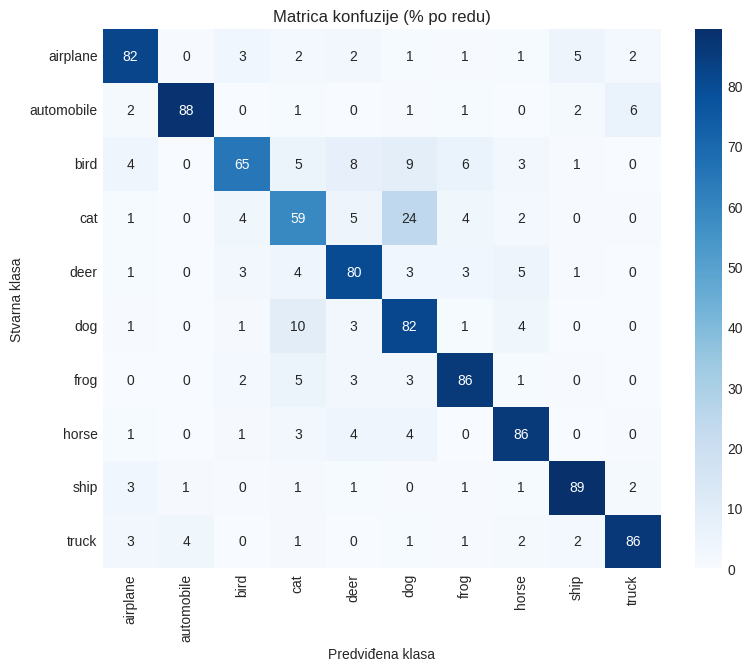

In [ ]:
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
plt.figure(figsize=(9, 7))
sns.heatmap(cm_pct, annot=True, fmt='.0f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predviđena klasa"); plt.ylabel("Stvarna klasa")
plt.title("Matrica konfuzije (% po redu)"); plt.show()

**Tačnost po klasi** — koje kategorije su modelu lake, a koje teške (sortirano).

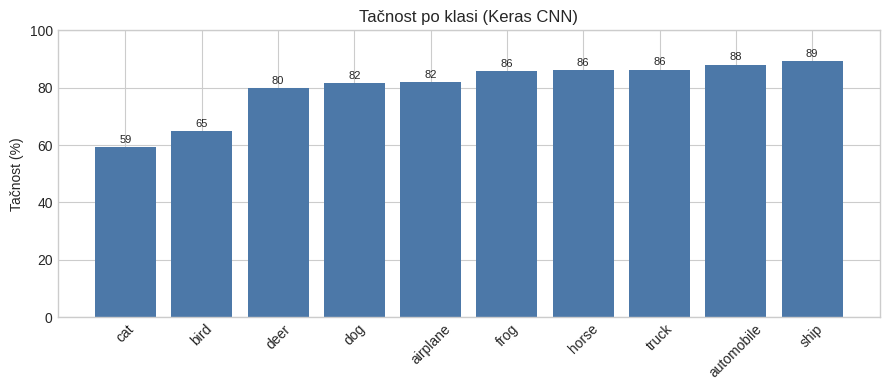

In [ ]:
per_class = cm.diagonal() / cm.sum(axis=1) * 100
order = np.argsort(per_class)
plt.figure(figsize=(9, 4))
plt.bar([class_names[i] for i in order], per_class[order], color='#4c78a8')
for i, v in enumerate(per_class[order]):
    plt.text(i, v+1.5, f"{v:.0f}", ha='center', fontsize=8)
plt.ylabel("Tačnost (%)"); plt.title(f"Tačnost po klasi ({best_name})"); plt.ylim(0, 100)
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

Automatski izvlačimo tri najčešće zamene klasa (najveće vrednosti van dijagonale).

In [ ]:
off = cm.copy(); np.fill_diagonal(off, 0)
print("Najčešće greške modela:")
for _ in range(3):
    i, j = np.unravel_index(off.argmax(), off.shape)
    print(f"  {class_names[i]} pogrešno kao {class_names[j]}: {off[i, j]} puta"); off[i, j] = 0

Najčešće greške modela:
  cat pogrešno kao dog: 243 puta
  dog pogrešno kao cat: 95 puta
  bird pogrešno kao dog: 90 puta


Preciznost, odziv i F1 po svakoj klasi za najbolji model.

In [ ]:
print(classification_report(y_true, best_pred, target_names=class_names, zero_division=0))

              precision    recall  f1-score   support

    airplane       0.84      0.82      0.83      1000
  automobile       0.94      0.88      0.91      1000
        bird       0.81      0.65      0.72      1000
         cat       0.65      0.59      0.62      1000
        deer       0.76      0.80      0.78      1000
         dog       0.64      0.81      0.71      1000
        frog       0.84      0.86      0.85      1000
       horse       0.83      0.86      0.85      1000
        ship       0.89      0.89      0.89      1000
       truck       0.88      0.86      0.87      1000

    accuracy                           0.80     10000
   macro avg       0.81      0.80      0.80     10000
weighted avg       0.81      0.80      0.80     10000



Kvalitativna provera: 10 stvarno pogrešno klasifikovanih slika (stvarno -> predviđeno).

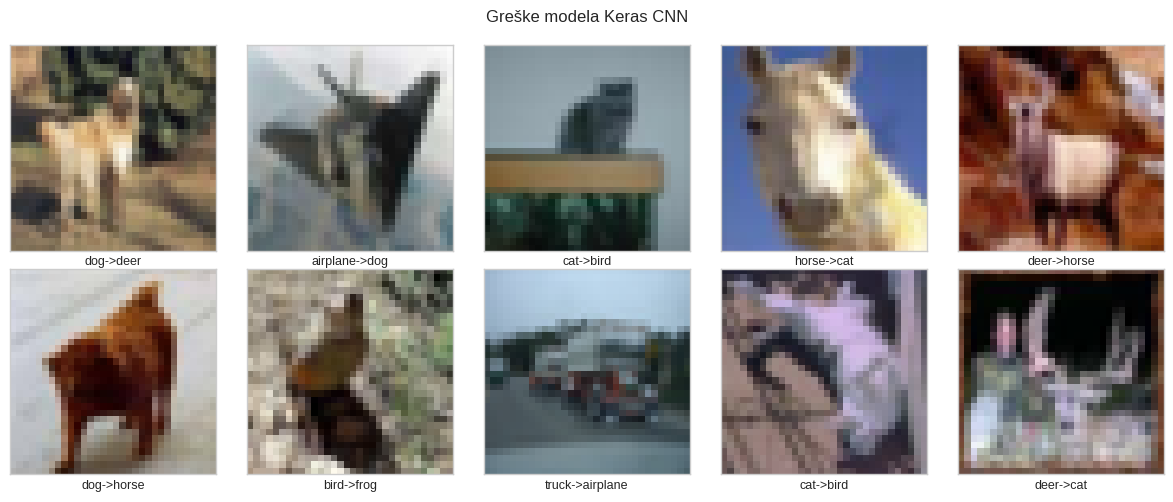

In [ ]:
wrong = np.where(best_pred != y_true)[0][:10]
plt.figure(figsize=(12, 5))
for k, idx in enumerate(wrong):
    plt.subplot(2, 5, k + 1); plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.imshow(x_test[idx]); plt.xlabel(f"{class_names[y_true[idx]]}->{class_names[best_pred[idx]]}", fontsize=9)
plt.suptitle(f"Greške modela {best_name}"); plt.tight_layout(); plt.show()

Primeri predikcija sa **samopouzdanjem** — koliko procenata model daje svojoj odluci (zeleno = tačno, crveno = greška).

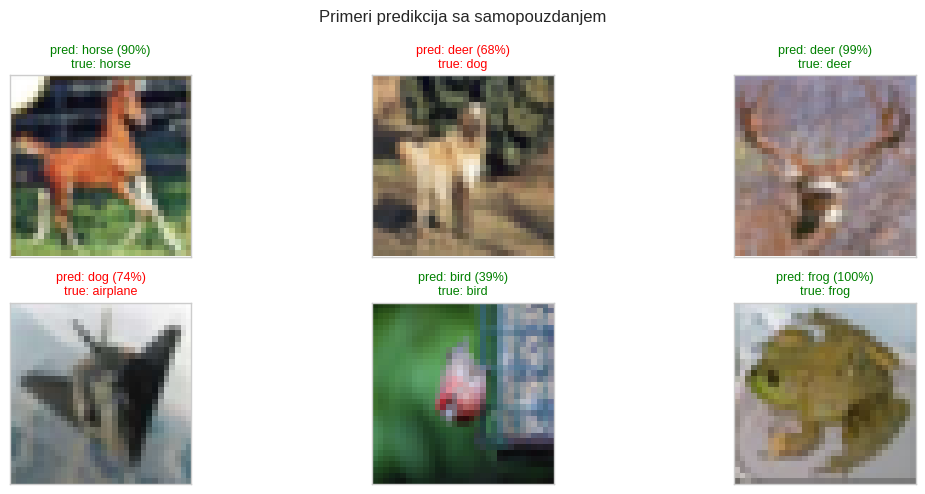

In [ ]:
show = np.arange(6)
probs = best_model.predict(x_test_norm[show], verbose=0)
plt.figure(figsize=(12, 5))
for k, ix in enumerate(show):
    pred = int(probs[k].argmax()); conf = probs[k][pred]*100; true = int(y_true[ix])
    plt.subplot(2, 3, k + 1); plt.xticks([]); plt.yticks([]); plt.grid(False); plt.imshow(x_test[ix])
    plt.title(f"pred: {class_names[pred]} ({conf:.0f}%)\ntrue: {class_names[true]}",
              color=('green' if pred == true else 'red'), fontsize=9)
plt.suptitle("Primeri predikcija sa samopouzdanjem"); plt.tight_layout(); plt.show()

Sve modele sažimamo u jednu tabelu: tačnost na testu i macro-F1.

In [ ]:
table = pd.DataFrame(
    [(n, f"{a*100:.2f}%", f"{f:.3f}") for n, (a, f) in results.items()],
    columns=["Model", "Tačnost (test)", "Macro-F1"])
table

,Model,Tačnost (test),Macro-F1
0,scikit-learn MLP,42.10%,0.415
1,Keras MLP,47.58%,0.468
2,Keras CNN,80.31%,0.803


## 6. Zaključak
Poređenje daje jasnu poentu: dve guste mreže (scikit-learn i Keras MLP) daju sličan rezultat, dok CNN ubedljivo pobeđuje jer poštuje prostornu strukturu slike — dakle arhitektura je važnija od biblioteke. CNN pokazuje umereno preobučavanje (razmak trening/validacija), koje bi se dalje smanjilo augmentacijom podataka. Najviše se mešaju vizuelno slične klase (mačka/pas). Budući pravci: augmentacija, Transfer Learning (ResNet/VGG) i optimizacija hiperparametara.